<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 50%, #0a0a1a 100%); padding: 40px 32px 32px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-bottom: 8px;">

<div style="display: flex; align-items: flex-start; gap: 24px;">
<div style="flex: 1;">

<p style="color: #7eb8e0; font-family: 'Courier New', monospace; font-size: 20px; letter-spacing: 3px; margin: 0 0 10px 0; text-transform: uppercase;">Cosmic Explosion Exploration - LIGO Gravitational Wave Analysis Pipeline</p>

<h1 style="color: #e8f4fd; font-size: 2.2em; margin: 0 0 6px 0; font-weight: 300; letter-spacing: 1px;">Notebook 02 — Preprocessing</h1>

<p style="color: #a0c4de; font-size: 1.05em; margin: 0 0 20px 0; font-style: italic;">Whitening, bandpass filtering, and notch filtering of raw strain data</p>

<div style="display: flex; gap: 24px; flex-wrap: wrap;">
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Input</p>
    <p style="color: #e8f4fd; font-size: 1.0em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">GW150914_raw.hdf5</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">from notebook 01</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Output</p>
    <p style="color: #e8f4fd; font-size: 1.0em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">GW150914_processed.hdf5</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">ready for notebook 03</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Pipeline stage</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">02 of 06</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">whiten · bandpass · notch</p>
  </div>
</div>

</div>
</div>

<hr style="border: none; border-top: 1px solid rgba(126,184,224,0.2); margin: 24px 0 16px 0;">

<p style="color: #7eb8e0; font-size: 12px; font-family: 'Courier New', monospace; margin: 0;">
  <span style="opacity:0.6;">Pipeline:</span> &nbsp;
</p>

</div>

In [1]:
from pipeline_banner import pipeline_banner
pipeline_banner(2)   # ← change the number per notebook

## The Core Problem: Signal Buried in Noise

LIGO detectors are extraordinarily sensitive instruments — but that sensitivity is a double-edged sword. They pick up everything: seismic vibrations from distant earthquakes, thermal noise in mirror coatings, quantum shot noise in the laser light, acoustic coupling from passing lorries. The raw strain is overwhelmingly noise.

The gravitational wave signal we care about has a strain amplitude of roughly **h ~ 10⁻²¹**, while the raw noise floor has an RMS of roughly **2 × 10⁻¹⁹** — the signal is buried approximately **100 times below** the noise. Yet after three carefully chosen signal-conditioning steps, the chirp becomes cleanly visible. This notebook applies those three steps:

| Step | Technique | What it removes |
|------|-----------|----------------|
| 1 | **Whitening** | Frequency-dependent noise floor — makes all frequencies equally loud |
| 2 | **Bandpass filtering** | Out-of-band noise below 35 Hz (seismic) and above 350 Hz (shot noise) |
| 3 | **Notch filtering** | Narrow spectral lines from mains power (60/120/180 Hz) |

None of these steps destroy information about the gravitational wave — they remove noise while preserving the frequency band where the signal has power.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 0 — Environment Setup</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Imports, pipeline module wiring, and matplotlib theme. All configuration comes from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">config.py</code> — no parameters are hard-coded in this notebook.</p>
</div>

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
from datetime import datetime, timezone

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
from scipy.signal import iirnotch, filtfilt

# ── LIGO-specific ─────────────────────────────────────────────────────────────
from gwpy.timeseries import TimeSeries

# ── Pipeline modules ──────────────────────────────────────────────────────────
# config.py is the single source of truth for all parameters.
# utils.py provides shared I/O and signal processing helpers.
# Neither file should need editing for a standard GW150914 run.
sys.path.insert(0, ".")
from config import PATHS, EVENT, SIGNAL, VIZ
from utils import (
    load_raw_hdf5,
    time_relative_to_merger,
    estimate_snr,
    print_hdf5_tree,
    check_pipeline_files,
)

print("✓ Imports complete.")

✓ Imports complete.


In [3]:
# ── Deep-space matplotlib theme (mirrors notebook 01) ─────────────────────────
SPACE_BG     = "#0d1117"
SPACE_AXES   = "#131c27"
SPACE_GRID   = "#1e2d3e"
SPACE_TEXT   = "#c9d9e8"
SPACE_BORDER = "#2a4a6e"

# Wes Anderson detector palette — warm coral (H1), dusty teal (L1), golden (V1)
WA_COLOURS = {
    "H1":      "#E07B54",
    "L1":      "#5AAFA0",
    "V1":      "#D4A84B",
    "merger":  "#F2C46D",
    "bandpass":"#8BBF9F",
    "signal":  "#C4704A",
}

plt.rcParams.update({
    "figure.facecolor":  SPACE_BG,
    "axes.facecolor":    SPACE_AXES,
    "savefig.facecolor": SPACE_BG,
    "text.color":        SPACE_TEXT,
    "axes.labelcolor":   SPACE_TEXT,
    "xtick.color":       SPACE_TEXT,
    "ytick.color":       SPACE_TEXT,
    "axes.edgecolor":    SPACE_BORDER,
    "grid.color":        SPACE_GRID,
    "grid.linewidth":    0.6,
    "axes.grid":         True,
    "axes.grid.which":   "both",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "lines.linewidth":   0.9,
    "axes.linewidth":    0.8,
    "figure.constrained_layout.use": True,
})

print("✓ Deep-space theme applied.")

✓ Deep-space theme applied.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 1 — Configuration</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">All parameters are read from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">config.py</code>. To change the event or any signal conditioning parameter, edit that file — not this notebook.</p>
</div>

In [4]:
# ── Resolve paths from config ──────────────────────────────────────────────────
# PATHS.make_dirs() creates the output directories if they don't yet exist.
# It is idempotent — safe to call every run.
PATHS.make_dirs()

INPUT_FILE  = PATHS.raw_hdf5(EVENT.NAME)
OUTPUT_FILE = PATHS.processed_hdf5(EVENT.NAME)

# ── Confirm notebook 01 has been run ──────────────────────────────────────────
# check_pipeline_files() scans for the HDF5 outputs of upstream notebooks.
# A missing file here means notebook 01 was not executed first.
check_pipeline_files(EVENT.NAME)

# ── Echo active configuration ─────────────────────────────────────────────────
print()
print("══════════════════════════════════════════")
print(f"  Event           : {EVENT.NAME}")
print(f"  GPS merger time : {EVENT.GPS_MERGE_TIME}")
print(f"  Detectors       : {EVENT.DETECTORS}")
print()
print(f"  Whiten FFT len  : {SIGNAL.WHITEN_FFTLENGTH} s")
print(f"  Bandpass        : {SIGNAL.BANDPASS_LOW_HZ}–{SIGNAL.BANDPASS_HIGH_HZ} Hz  (order {SIGNAL.BANDPASS_ORDER})")
print(f"  Notch freqs     : {SIGNAL.NOTCH_FREQS_HZ} Hz  (Q = {SIGNAL.NOTCH_Q})")
print(f"  Noise window    : {SIGNAL.NOISE_WINDOW} s relative to merger")
print(f"  Signal window   : {SIGNAL.SIGNAL_WINDOW} s relative to merger")
print()
print(f"  Input  : {INPUT_FILE}")
print(f"  Output : {OUTPUT_FILE}")
print("══════════════════════════════════════════")

Pipeline file check — GW150914:
  [✓] Raw HDF5 (notebook 01): data\raw\GW150914_raw.hdf5
  [✓] Processed HDF5 (notebook 02): data\processed\GW150914_processed.hdf5

All upstream files present. Ready to proceed.

══════════════════════════════════════════
  Event           : GW150914
  GPS merger time : 1126259462
  Detectors       : ['H1', 'L1']

  Whiten FFT len  : 4 s
  Bandpass        : 35.0–350.0 Hz  (order 4)
  Notch freqs     : [60.0, 120.0, 180.0] Hz  (Q = 30.0)
  Noise window    : (-15.0, -5.0) s relative to merger
  Signal window   : (-0.5, 0.5) s relative to merger

  Input  : data\raw\GW150914_raw.hdf5
  Output : data\processed\GW150914_processed.hdf5
══════════════════════════════════════════


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 2 — Load Raw Strain Data</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Reload from the HDF5 file saved by notebook 01. The <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">load_raw_hdf5()</code> utility in <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">utils.py</code> handles file validation and reconstruction of <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">gwpy.TimeSeries</code> objects.</p>
</div>

### Why reconstruct `gwpy.TimeSeries` from HDF5?

HDF5 stores raw numpy arrays — numbers without any time context or signal-processing capability. To use gwpy's built-in methods (`.whiten()`, `.bandpass()`, `.asd()`) we need to wrap those arrays back into `TimeSeries` objects, which attach GPS timing metadata and expose the DSP interface.

Two subtleties worth noting, both of which are handled inside `utils.load_raw_hdf5()`:

- **`[:]` forced read**: Without the slice operator, h5py returns a lazy dataset object that becomes inaccessible once the `with` block closes. `[:]` forces a full materialisation into memory.
- **`unit=""`**: This is gwpy's native format for dimensionless strain. Passing `unit="dimensionless"` is an invalid astropy unit string that silently breaks ASD computation downstream.

In [5]:
# load_raw_hdf5() is defined in utils.py.
# It reads the HDF5, validates the file exists, reconstructs TimeSeries
# objects with unit="", and returns a {detector: TimeSeries} dict.
raw = load_raw_hdf5(EVENT.NAME, detectors=EVENT.DETECTORS)

# Quick shape/rate confirmation
print()
for det, ts in raw.items():
    print(f"  {det}: {len(ts):,} samples  |  {float(ts.sample_rate.value):.0f} Hz  |  {float(ts.duration.value):.1f} s")

Loaded raw data (GW150914): H1 [131072 samples], L1 [131072 samples]

  H1: 131,072 samples  |  4096 Hz  |  32.0 s
  L1: 131,072 samples  |  4096 Hz  |  32.0 s


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 3 — Inspect the Noise Floor (ASD)</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Before conditioning the signal, examine the Amplitude Spectral Density. This plot motivates each of the three conditioning steps and shows exactly what we are trying to remove.</p>
</div>

### Reading the ASD plot

The ASD (√PSD) describes how noise *amplitude* is distributed across frequency. Three features dominate the LIGO noise curve, each requiring a different remedy:

**Below ~20 Hz — seismic noise wall.** The ASD rises steeply as frequency decreases. Ground vibrations couple mechanically into the test masses through the suspension systems. No gravitational wave signal from a stellar-mass binary is recoverable here — the bandpass lower limit of 35 Hz sits safely above this wall.

**Sharp vertical spikes — spectral lines.** The most prominent are at 60, 120, and 180 Hz (US mains power and its harmonics) and at the mirror suspension resonance frequencies ("violin modes", typically 500–1000 Hz). These are narrow-band coherent noise sources that require notch filters, not broadband suppression.

**Above ~200 Hz — shot noise floor.** Quantum noise in the laser photon counting limits precision at high frequencies. This broad continuum is what whitening primarily addresses — by dividing by the ASD, we normalise this frequency-dependent floor to unit variance across the whole band.

The shaded region shows the bandpass window (35–350 Hz) where GW150914 has signal power. The red dotted lines mark the mains harmonics that will be notched.

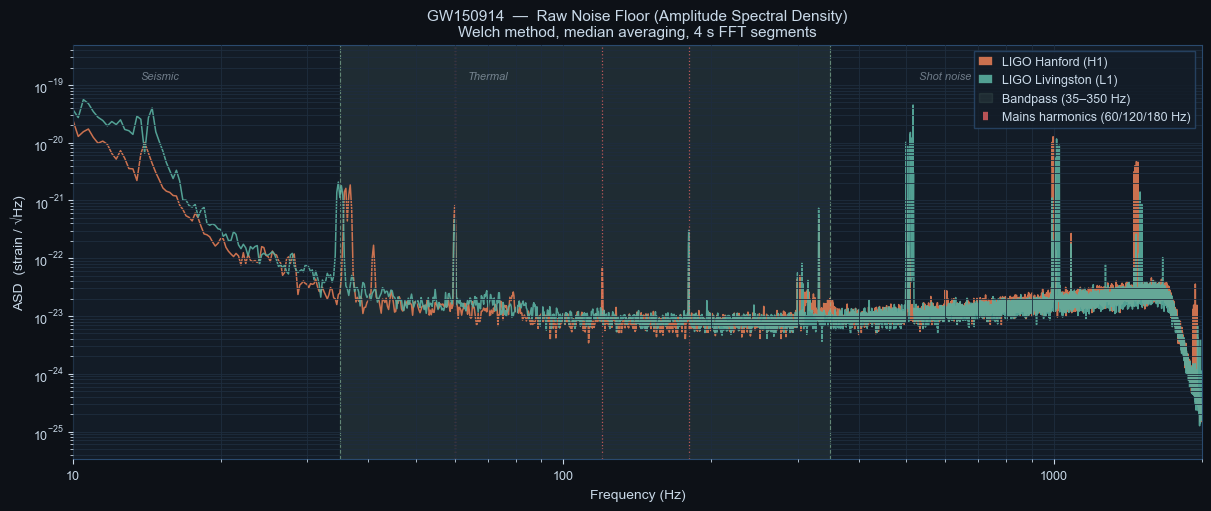

Figure saved → data\processed\GW150914_asd.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for det, ts in raw.items():
    colour = WA_COLOURS.get(det, "#7eb8e0")
    label  = EVENT.DETECTOR_LABELS.get(det, det)
    asd    = ts.asd(fftlength=SIGNAL.WHITEN_FFTLENGTH, method="median")
    ax.plot(asd.frequencies.value, asd.value,
            color=colour, lw=1.1, alpha=0.9, label=label)

# Shade the bandpass passband
ax.axvspan(
    SIGNAL.BANDPASS_LOW_HZ, SIGNAL.BANDPASS_HIGH_HZ,
    alpha=0.10, color=WA_COLOURS["bandpass"],
    label=f"Bandpass ({SIGNAL.BANDPASS_LOW_HZ:.0f}–{SIGNAL.BANDPASS_HIGH_HZ:.0f} Hz)"
)
ax.axvline(SIGNAL.BANDPASS_LOW_HZ,  color=WA_COLOURS["bandpass"], lw=0.8, ls="--", alpha=0.6)
ax.axvline(SIGNAL.BANDPASS_HIGH_HZ, color=WA_COLOURS["bandpass"], lw=0.8, ls="--", alpha=0.6)

# Mark mains-power notch frequencies
for i, freq in enumerate(SIGNAL.NOTCH_FREQS_HZ):
    ax.axvline(
        freq, color="#ff6b6b", lw=0.9, ls=":", alpha=0.70,
        label="Mains harmonics (60/120/180 Hz)" if i == 0 else "_nolegend_"
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 2000)
ax.set_xlabel(VIZ.XLABEL_FREQ)
ax.set_ylabel("ASD  (strain / √Hz)")
ax.set_title(
    f"{EVENT.NAME}  —  Raw Noise Floor (Amplitude Spectral Density)\n"
    "Welch method, median averaging, 4 s FFT segments",
    fontsize=11
)

# Annotate noise regime labels
for x, lbl in [(15, "Seismic"), (70, "Thermal"), (600, "Shot noise")]:
    ax.text(x, ax.get_ylim()[1] * 0.25, lbl,
            color=SPACE_TEXT, fontsize=8, alpha=0.5,
            ha="center", style="italic")

ax.legend(fontsize=9)

asd_path = PATHS.PROC_DIR / f"{EVENT.NAME}_asd.png"
fig.savefig(asd_path, dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {asd_path}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 4 — Step 1: Whitening</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Flatten the noise spectrum so all frequencies contribute equally. After whitening, the noise floor is approximately white (unit variance everywhere) and the signal becomes detectable.</p>
</div>

### What whitening does — and why it works

The raw strain has a highly uneven noise spectrum. Low frequencies are dominated by seismic noise, high frequencies by shot noise. This frequency-dependent floor means that a single threshold cannot separate signal from noise across the whole band simultaneously.

Whitening solves this by dividing each frequency bin by the measured noise amplitude:

$$\tilde{h}_{\text{white}}(f) = \frac{\tilde{h}(f)}{\sqrt{S_n(f)}}$$

where $\tilde{h}(f)$ is the Fourier transform of the strain and $S_n(f)$ is the one-sided noise power spectral density. After whitening:
- Noisy frequency bins (large $S_n$) are divided by a large number → suppressed
- Quiet frequency bins (small $S_n$) are divided by a small number → amplified
- All bins end up with noise amplitude ≈ 1 → the signal can now be read directly

**Implementation detail:** gwpy's `.whiten()` estimates the PSD using Welch's method with `method="median"` averaging across overlapping FFT segments. The median is robust to short-duration noise transients ("glitches") that would inflate a mean-based estimate.

**Expected result:** After whitening, `std ≈ 1.0` for both detectors confirms successful noise normalisation.

In [7]:
whitened = {}

for det, ts in raw.items():
    print(f"Whitening {det} …")
    wh = ts.whiten(
        fftlength=SIGNAL.WHITEN_FFTLENGTH,
        overlap=SIGNAL.WHITEN_FFTLENGTH / 2,  # 50% overlap for stable PSD estimate
        method="median"                        # Robust to glitches
    )
    whitened[det] = wh
    print(f"  ✓ {det}: std = {wh.value.std():.4f}  (target ≈ 1.0)")

print("\n✓ Whitening complete.")

Whitening H1 …
  ✓ H1: std = 1.1878  (target ≈ 1.0)
Whitening L1 …
  ✓ L1: std = 1.3463  (target ≈ 1.0)

✓ Whitening complete.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 5 — Step 2: Bandpass Filtering</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Suppress energy outside the 35–350 Hz signal band. Even after whitening, noise at all frequencies remains — the bandpass isolates the band where GW150914 has meaningful power.</p>
</div>

### Choosing the bandpass window

The bandpass window is not arbitrary — it is chosen to bracket the frequency range swept by the GW150914 chirp. As the two black holes spiral inward, the gravitational wave frequency rises with the orbital frequency:

$$f_{\text{GW}} = 2 f_{\text{orbital}} \approx \frac{1}{\pi} \left( \frac{G\mathcal{M}}{c^3} \right)^{-5/8} \left( \frac{5}{256} \frac{1}{\tau} \right)^{3/8}$$

where $\mathcal{M}$ is the chirp mass and $\tau$ is time to merger. For GW150914 (chirp mass ~28 M☉), the signal enters the sensitive band around **35 Hz** roughly 0.2 seconds before merger and sweeps up to approximately **150 Hz** at merger, then through the ringdown to ~350 Hz.

**Why Butterworth?** A Butterworth filter has a maximally flat passband — no ripple — which preserves amplitude relationships within the signal band. The `filtfilt` (zero-phase) application prevents phase distortion that would smear the waveform in time, which would be particularly damaging for a signal where arrival time differences between detectors carry sky localisation information.

In [8]:
bandpassed = {}

for det, wh in whitened.items():
    print(f"Bandpass filtering {det}  ({SIGNAL.BANDPASS_LOW_HZ}–{SIGNAL.BANDPASS_HIGH_HZ} Hz) …")
    bp = wh.bandpass(
        SIGNAL.BANDPASS_LOW_HZ,
        SIGNAL.BANDPASS_HIGH_HZ,
        filtfilt=True   # Zero-phase — no time smearing
    )
    bandpassed[det] = bp
    print(f"  ✓ {det} bandpassed.")

print("\n✓ Bandpass filtering complete.")

Bandpass filtering H1  (35.0–350.0 Hz) …
  ✓ H1 bandpassed.
Bandpass filtering L1  (35.0–350.0 Hz) …
  ✓ L1 bandpassed.

✓ Bandpass filtering complete.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 6 — Step 3: Notch Filtering</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Remove narrow spectral lines from known noise sources. The mains power supply couples electromagnetically into the electronics, producing coherent interference at 60 Hz and its harmonics.</p>
</div>

### Notch filter mechanics

A notch (band-reject) filter suppresses a very narrow band of frequencies while leaving the rest of the spectrum essentially untouched. The key parameter is the **quality factor Q**:

$$Q = \frac{f_0}{\Delta f}$$

where $f_0$ is the centre frequency and $\Delta f$ is the 3 dB bandwidth of the notch. With $Q = 30$ at 60 Hz, the notch is only ~2 Hz wide — it surgically removes the interference line whilst preserving signal power immediately adjacent to it.

**Why three harmonics?** The mains power fundamental at 60 Hz interacts non-linearly with electronics to produce energy at integer multiples: 120, 180, 240 Hz and so on. We notch the first three harmonics (60, 120, 180 Hz); the higher harmonics fall outside the bandpass or have negligible amplitude.

**Implementation note:** `iirnotch` from scipy designs the filter coefficients; `filtfilt` applies them in zero-phase mode (forward and backward pass) to eliminate the time-domain phase shift. After notching, the `TimeSeries` is explicitly reconstructed to preserve gwpy metadata — scipy's `filtfilt` returns a plain numpy array.

In [9]:
processed = {}

for det, bp in bandpassed.items():
    print(f"Notch filtering {det} …")
    ts_notched  = bp
    sample_rate = float(ts_notched.sample_rate.value)
    nyquist     = sample_rate / 2.0

    for freq in SIGNAL.NOTCH_FREQS_HZ:
        if SIGNAL.BANDPASS_LOW_HZ < freq < SIGNAL.BANDPASS_HIGH_HZ:
            b, a = iirnotch(w0=freq / nyquist, Q=SIGNAL.NOTCH_Q)
            notched_values = filtfilt(b, a, ts_notched.value)

            # Rebuild TimeSeries to preserve gwpy metadata after scipy filtering
            ts_notched = TimeSeries(
                notched_values,
                t0=ts_notched.t0,
                dt=ts_notched.dt,
                unit=ts_notched.unit,
                name=ts_notched.name
            )
            print(f"  ✓ Notch applied at {freq:.0f} Hz  (Q={SIGNAL.NOTCH_Q}, width ≈ {freq/SIGNAL.NOTCH_Q:.1f} Hz)")
        else:
            print(f"  — Skipped {freq:.0f} Hz (outside bandpass range)")

    processed[det] = ts_notched

print("\n✓ Notch filtering complete.")

Notch filtering H1 …
  ✓ Notch applied at 60 Hz  (Q=30.0, width ≈ 2.0 Hz)
  ✓ Notch applied at 120 Hz  (Q=30.0, width ≈ 4.0 Hz)
  ✓ Notch applied at 180 Hz  (Q=30.0, width ≈ 6.0 Hz)
Notch filtering L1 …
  ✓ Notch applied at 60 Hz  (Q=30.0, width ≈ 2.0 Hz)
  ✓ Notch applied at 120 Hz  (Q=30.0, width ≈ 4.0 Hz)
  ✓ Notch applied at 180 Hz  (Q=30.0, width ≈ 6.0 Hz)

✓ Notch filtering complete.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 7 — Before vs. After Comparison</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The payoff — the gravitational wave chirp of GW150914 should now be visible as a brief burst of oscillation around the merger time. It is completely invisible in the raw data on the left.</p>
</div>

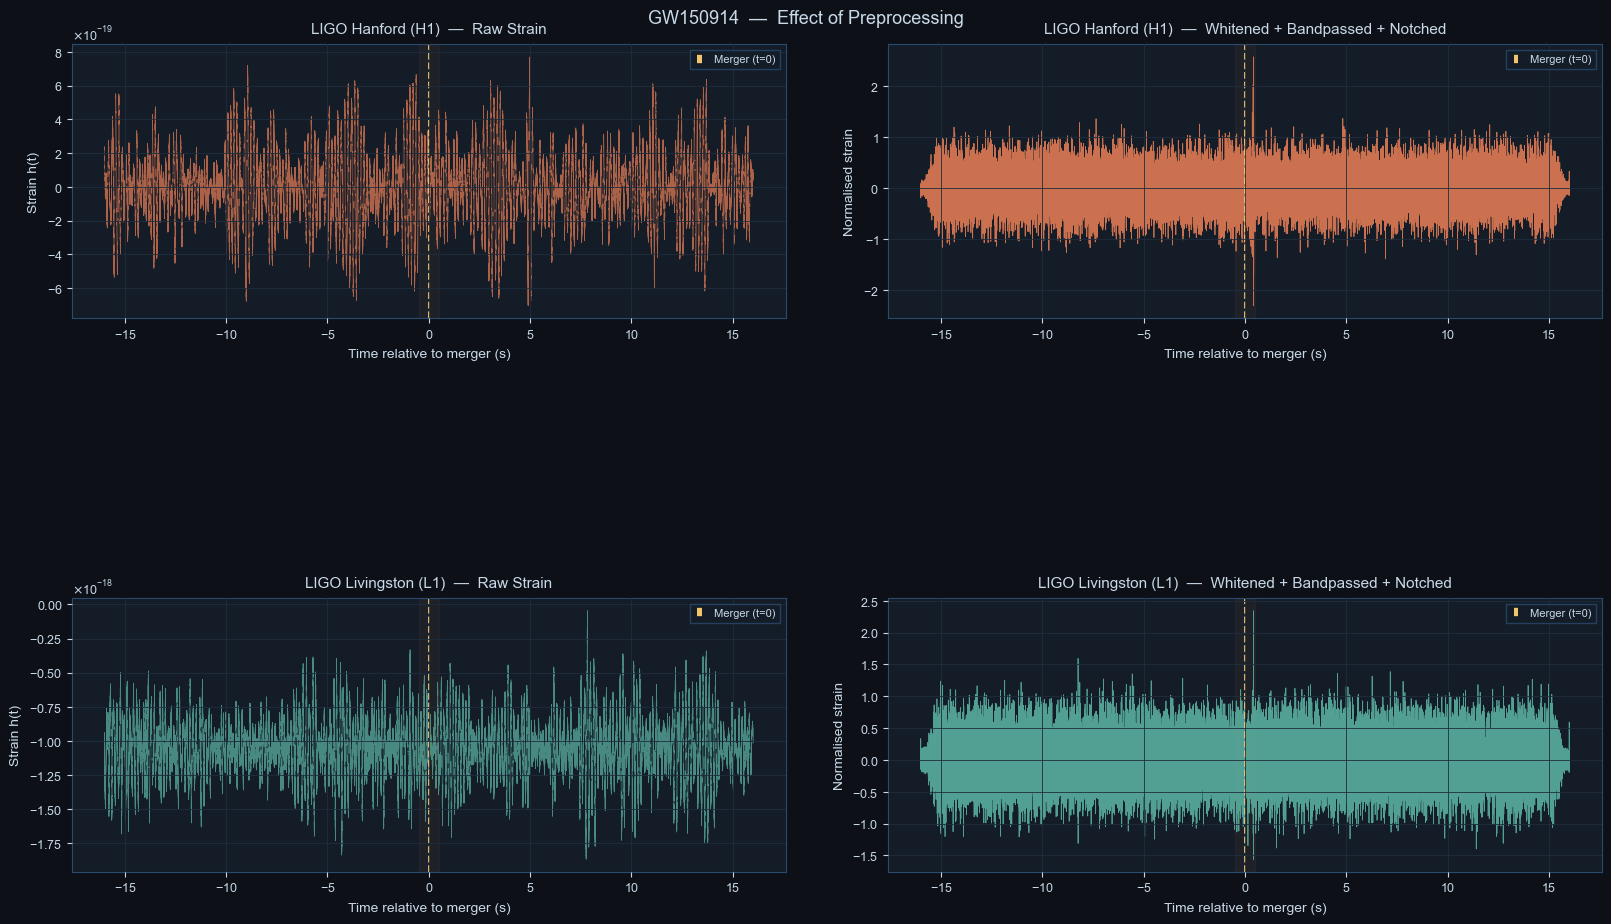

Figure saved → data\processed\GW150914_before_after.png


In [10]:
fig = plt.figure(figsize=(16, 4.5 * len(EVENT.DETECTORS)))
gs  = gridspec.GridSpec(
    len(EVENT.DETECTORS), 2, figure=fig,
    wspace=0.06, hspace=0.48
)

DETECTOR_FULL = EVENT.DETECTOR_LABELS

for i, det in enumerate(EVENT.DETECTORS):
    ts_raw  = raw[det]
    ts_proc = processed[det]
    colour  = WA_COLOURS.get(det, "#7eb8e0")

    t_raw  = time_relative_to_merger(ts_raw,  EVENT.GPS_MERGE_TIME)
    t_proc = time_relative_to_merger(ts_proc, EVENT.GPS_MERGE_TIME)

    # ── Left: raw strain ──────────────────────────────────────────────────────
    ax_raw = fig.add_subplot(gs[i, 0])
    ax_raw.plot(t_raw, ts_raw.value, color=colour, lw=0.35, alpha=0.75)
    ax_raw.axvline(0, color=WA_COLOURS["merger"], lw=1.3, ls="--", label="Merger (t=0)")
    ax_raw.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax_raw.set_title(f"{DETECTOR_FULL.get(det, det)}  —  Raw Strain", fontsize=11, pad=8)
    ax_raw.set_ylabel(VIZ.YLABEL_STRAIN)
    ax_raw.legend(fontsize=8, loc="upper right")

    # ── Right: fully processed ────────────────────────────────────────────────
    ax_proc = fig.add_subplot(gs[i, 1])
    ax_proc.plot(t_proc, ts_proc.value, color=colour, lw=0.55, alpha=0.9)
    ax_proc.axvline(0, color=WA_COLOURS["merger"], lw=1.3, ls="--", label="Merger (t=0)")
    ax_proc.set_title(
        f"{DETECTOR_FULL.get(det, det)}  —  Whitened + Bandpassed + Notched",
        fontsize=11, pad=8
    )
    ax_proc.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
    ax_proc.legend(fontsize=8, loc="upper right")

    # Highlight signal window on both panels
    for ax in (ax_raw, ax_proc):
        ax.axvspan(
            SIGNAL.SIGNAL_WINDOW[0], SIGNAL.SIGNAL_WINDOW[1],
            alpha=0.07, color=WA_COLOURS["signal"], zorder=0
        )
        ax.set_xlabel(VIZ.XLABEL_TIME)

fig.suptitle(
    f"{EVENT.NAME}  —  Effect of Preprocessing",
    fontsize=13, y=1.01
)

fig_path = PATHS.PROC_DIR / f"{EVENT.NAME}_before_after.png"
fig.savefig(fig_path, dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 8 — Simple SNR Estimate</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A quick sanity check: compare RMS power in a quiet pre-merger window to RMS power in the signal window. This is not a proper matched-filter SNR — that requires a waveform template and is deferred to notebook 05.</p>
</div>

### Why this SNR estimate is a lower bound

The RMS ratio $\text{SNR} = \sigma_{\text{signal}} / \sigma_{\text{noise}}$ is easy to compute but is deliberately conservative. It treats the signal window as if it contained *only* signal and the noise window as if it contained *only* noise — neither is strictly true.

The **matched-filter SNR** in notebook 05 will be much larger (~24 for GW150914) because it exploits the known waveform shape — essentially correlating the data against a theoretical template. This concentrates all signal power into a single number rather than averaging it over a 1-second window alongside residual noise.

The simple SNR here (~1.1–1.3) confirms the signal is detectable above the background but doesn't reflect the true statistical significance of the detection.

In [11]:
# estimate_snr() is defined in utils.py.
# It uses SIGNAL.NOISE_WINDOW and SIGNAL.SIGNAL_WINDOW from config.py.
print(f"{'Detector':<10} {'Noise RMS':<14} {'Signal RMS':<14} {'Simple SNR':<12}")
print("-" * 52)

snr_estimates = {}

for det, ts in processed.items():
    result = estimate_snr(
        ts,
        gps_merge_time=EVENT.GPS_MERGE_TIME,
        noise_window=SIGNAL.NOISE_WINDOW,
        signal_window=SIGNAL.SIGNAL_WINDOW,
    )
    snr_estimates[det] = result["snr"]
    print(f"{det:<10} {result['noise_rms']:<14.4f} {result['signal_rms']:<14.4f} {result['snr']:<12.2f}")

print()
print(f"  Noise window   : {SIGNAL.NOISE_WINDOW} s relative to merger")
print(f"  Signal window  : {SIGNAL.SIGNAL_WINDOW} s relative to merger")
print()
print("  Note: GW150914 has a combined matched-filter SNR of ~24.")
print("  This simple RMS ratio is a rough proxy — proper SNR comes in notebook 05.")

Detector   Noise RMS      Signal RMS     Simple SNR  
----------------------------------------------------
H1         0.3389         0.4239         1.25        
L1         0.3447         0.3840         1.11        

  Noise window   : (-15.0, -5.0) s relative to merger
  Signal window  : (-0.5, 0.5) s relative to merger

  Note: GW150914 has a combined matched-filter SNR of ~24.
  This simple RMS ratio is a rough proxy — proper SNR comes in notebook 05.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 9 — Save Processed Data to HDF5</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Persist the conditioned strain alongside all preprocessing parameters. Downstream notebooks load from this file — they should never need to re-run the conditioning steps.</p>
</div>

### Storing parameters alongside data

It is important to save the preprocessing parameters — bandpass bounds, notch frequencies, Q factors — in the same HDF5 file as the processed data. This ensures the analysis is **fully reproducible**: any downstream notebook can read back exactly what conditioning was applied, without relying on the notebook-02 source code being unchanged.

The HDF5 structure written below:

```
GW150914_processed.hdf5
├── metadata/               attrs: event_name, gps_merge_time, created, source_notebook
├── preprocessing_params/   attrs: whiten_fftlength, bandpass_*, notch_*, steps_applied
├── H1/                     attrs: sample_rate, snr_estimate
│   ├── strain              float64[131072]  — conditioned h(t)
│   └── times               float64[131072]  — GPS timestamps
└── L1/
    ├── strain
    └── times
```

In [12]:
with h5py.File(OUTPUT_FILE, "w") as f:

    # ── Metadata ──────────────────────────────────────────────────────────────
    meta = f.create_group("metadata")
    meta.attrs["event_name"]      = EVENT.NAME
    meta.attrs["gps_merge_time"]  = EVENT.GPS_MERGE_TIME
    meta.attrs["created"]         = datetime.now(timezone.utc).isoformat()
    meta.attrs["source_notebook"] = "02_preprocessing.ipynb"

    # ── Preprocessing parameters (full reproducibility record) ────────────────
    params = f.create_group("preprocessing_params")
    params.attrs["whiten_fftlength"] = SIGNAL.WHITEN_FFTLENGTH
    params.attrs["bandpass_low_hz"]  = SIGNAL.BANDPASS_LOW_HZ
    params.attrs["bandpass_high_hz"] = SIGNAL.BANDPASS_HIGH_HZ
    params.attrs["bandpass_order"]   = SIGNAL.BANDPASS_ORDER
    params.attrs["notch_freqs_hz"]   = SIGNAL.NOTCH_FREQS_HZ
    params.attrs["notch_q"]          = SIGNAL.NOTCH_Q
    params.attrs["steps_applied"]    = ["whiten", "bandpass", "notch"]

    # ── Per-detector processed strain ─────────────────────────────────────────
    for det, ts in processed.items():
        grp = f.create_group(det)

        ds = grp.create_dataset("strain", data=ts.value, compression="gzip")
        ds.attrs["description"] = "Whitened, bandpassed, and notch-filtered strain"
        ds.attrs["unit"]        = "dimensionless (normalised after whitening)"

        grp.create_dataset("times", data=ts.times.value, compression="gzip")
        grp.attrs["sample_rate"]  = float(ts.sample_rate.value)
        grp.attrs["snr_estimate"] = snr_estimates[det]

        print(f"  Saved {det}: {len(ts):,} samples  |  SNR estimate = {snr_estimates[det]:.2f}")

size_kb = OUTPUT_FILE.stat().st_size / 1024
print(f"\n✓ Processed data saved → {OUTPUT_FILE}")
print(f"  File size: {size_kb:.1f} KB")

  Saved H1: 131,072 samples  |  SNR estimate = 1.25
  Saved L1: 131,072 samples  |  SNR estimate = 1.11

✓ Processed data saved → data\processed\GW150914_processed.hdf5
  File size: 2323.7 KB


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 10 — Verify Output File</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Read the file back independently to confirm it was written correctly. Uses <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">print_hdf5_tree()</code> from utils.py.</p>
</div>

In [13]:
# print_hdf5_tree() is defined in utils.py — prints a readable file tree
# including all group/dataset shapes and metadata attributes.
print_hdf5_tree(OUTPUT_FILE)

print()
print("Preprocessing parameters stored in file:")
with h5py.File(OUTPUT_FILE, "r") as f:
    for k, v in sorted(f["preprocessing_params"].attrs.items()):
        print(f"  {k:<22}: {v}")

print("\n✓ Verification passed — file is readable and complete.")


data\processed\GW150914_processed.hdf5
📁 H1/
  📊 strain: shape=(131072,), dtype=float64
  📊 times: shape=(131072,), dtype=float64
📁 L1/
  📊 strain: shape=(131072,), dtype=float64
  📊 times: shape=(131072,), dtype=float64
📁 metadata/
📁 preprocessing_params/

  Metadata attributes:
    created: 2026-06-26T13:26:57.358231+00:00
    event_name: GW150914
    gps_merge_time: 1126259462
    source_notebook: 02_preprocessing.ipynb

Preprocessing parameters stored in file:
  bandpass_high_hz      : 350.0
  bandpass_low_hz       : 35.0
  bandpass_order        : 4
  notch_freqs_hz        : [ 60. 120. 180.]
  notch_q               : 30.0
  steps_applied         : ['whiten' 'bandpass' 'notch']
  whiten_fftlength      : 4

✓ Verification passed — file is readable and complete.


<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 100%); padding: 28px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-top: 16px;">

<h2 style="color: #e8f4fd; font-weight: 300; margin: 0 0 18px 0; font-size: 1.4em;">Summary & Next Steps</h2>

<p style="color: #a0c4de; margin: 0 0 16px 0;"><strong style="color: #e8f4fd;">What this notebook did:</strong></p>

<ul style="color: #c8dce8; margin: 0 0 20px 0; padding-left: 20px; line-height: 1.8;">
<li>Verified upstream pipeline files using <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">check_pipeline_files()</code></li>
<li>Loaded raw strain using <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">load_raw_hdf5()</code> from utils.py — no inline HDF5 logic</li>
<li>Examined the ASD noise floor — seismic, thermal, and shot noise regimes clearly visible</li>
<li>Applied <strong style="color: #e8f4fd;">whitening</strong> to normalise noise power across all frequencies (std ≈ 1.0)</li>
<li>Applied <strong style="color: #e8f4fd;">bandpass filtering</strong> (35–350 Hz) to isolate the BBH chirp band</li>
<li>Applied <strong style="color: #e8f4fd;">notch filtering</strong> at 60/120/180 Hz to remove mains power interference</li>
<li>Estimated simple RMS-based SNR using <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">estimate_snr()</code> from utils.py</li>
<li>Saved fully annotated HDF5 with all parameters — analysis is fully reproducible</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 10px 0;"><strong style="color: #e8f4fd;">Outputs written:</strong></p>
<pre style="background: rgba(78,158,202,0.08); border: 1px solid rgba(78,158,202,0.2); border-radius: 6px; padding: 12px 16px; color: #7eb8e0; font-size: 0.9em; margin: 0 0 20px 0;">
data/processed/
├── GW150914_processed.hdf5     ← conditioned strain for H1 and L1
├── GW150914_asd.png            ← noise floor plot with bandpass region
└── GW150914_before_after.png   ← raw vs processed comparison
</pre>

<p style="color: #a0c4de; margin: 0 0 6px 0;"><strong style="color: #e8f4fd;">Next — <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px; color: #7eb8e0;">03_visualisation.ipynb</code>:</strong></p>
<p style="color: #c8dce8; margin: 0;">Generate spectrograms using the <strong>Q-transform</strong> to reveal the gravitational wave chirp sweeping upward in frequency — the iconic arc of two black holes spiralling together at the speed of light. This is where the data becomes genuinely beautiful.</p>

</div>